In [29]:
import pandas as pd
from braincoder.models import GaussianPRF

import numpy as np

from neural_priors.utils.data import Subject
from neural_priors.encoding_model.fit_model import get_paradigm, get_model
from pathlib import Path

from braincoder.utils import get_rsq
from braincoder.utils.math import get_expected_value, get_sd_posterior
from braincoder.optimize import ResidualFitter
from tqdm.contrib.itertools import product
import seaborn as sns

In [30]:
bids_folder = Path('/data/ds-neuralpriors')

subjects = list(range(1, 42))
# subjects.remove(23)

model_labels =[15, 18, 31]
fit_responses = [False]
many_samples = [False, True]
wide = [False, True]

smoothed = True

E = []
sd = []
keys = [] 

pars = []

for subject, model_label, fit_response, spherical_noise, many_samples_, wide_ in product(subjects, model_labels, fit_responses, [True], many_samples, wide):

        # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if fit_response:
        key += '.fit_responses'

    if wide_:
        key += '.wide'

    d = 'expected_uncertainty'

    if not many_samples_:
        d += '.bak'

    target_dir = Path(bids_folder) / 'derivatives' / d / key / f'sub-{subject:02d}' / 'func'

    try:
        # fi = pd.read_csv(target_dir / f'sub-{subject:02d}_desc-fisher_information.tsv', sep='\t')

        pars.append(pd.read_csv(target_dir / f'sub-{subject:02d}_desc-expected_error.tsv', sep='\t'))

    except FileNotFoundError as e:
        print(f'File not found for subject {subject}, model {model_label}, fit_response {fit_response}: {e}')
    
        continue

    # fisher_information.append(fi)
    keys.append((subject , model_label, fit_response, smoothed, spherical_noise, many_samples_, wide_))

# Concatenate all dataframes
# fisher_information = pd.concat(fisher_information, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed'])
# E = pd.concat(E, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise', 'many_samples'])
# sd = pd.concat(sd, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise', 'many_samples'])

pars = pd.concat(pars, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise', 'many_samples', 'wide'])

  0%|          | 0/492 [00:00<?, ?it/s]

File not found for subject 1, model 15, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty.bak/model15.smoothed.spherical_noise.wide/sub-01/func/sub-01_desc-expected_error.tsv'
File not found for subject 1, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty.bak/model18.smoothed.spherical_noise.wide/sub-01/func/sub-01_desc-expected_error.tsv'
File not found for subject 2, model 15, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty.bak/model15.smoothed.spherical_noise.wide/sub-02/func/sub-02_desc-expected_error.tsv'
File not found for subject 2, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty.bak/model18.smoothed.spherical_noise.wide/sub-02/func/sub-02_desc-expected_error.tsv'
File not found for subject 3, model 15, fit_

In [31]:
pars.to_csv(bids_folder / 'derivatives' / 'expected_uncertainty' / 'expected_uncertainty.tsv', sep='\t')

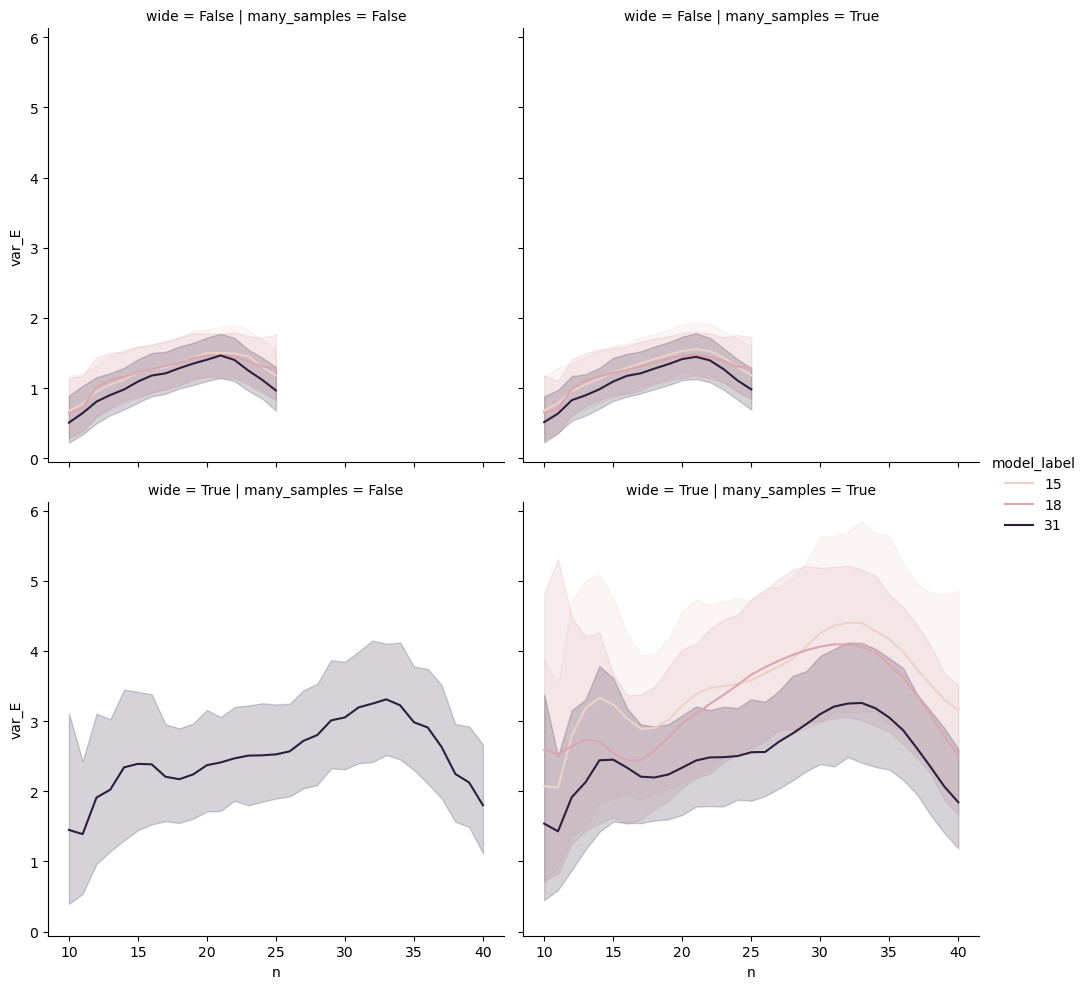

In [32]:
p = pars.groupby(['subject', 'n', 'model_label', 'many_samples', 'wide'])['var_E'].mean().reset_index()

sns.relplot(x='n', y='var_E', hue='model_label', col='many_samples', row='wide', data=p, kind='line')

In [33]:
p.query('n == 10.0').groupby(['model_label', 'many_samples', 'wide', 'subject']).size().unstack(['model_label', 'many_samples', 'wide'])

model_label     15                18                31                  
many_samples False True        False True        False       True       
wide         False False True  False False True  False True  False True 
subject                                                                 
1                1     1     1     1     1     1     1     1     1     1
2                1     1     1     1     1     1     1     1     1     1
3                1     1     1     1     1     1     1     1     1     1
4                1     1     1     1     1     1     1     1     1     1
5                1     1     1     1     1     1     1     1     1     1
6                1     1     1     1     1     1     1     1     1     1
7                1     1     1     1     1     1     1     1     1     1
8                1     1     1     1     1     1     1     1     1     1
9                1     1     1     1     1     1     1     1     1     1
10               1     1     1     1     1     1     1     1     1     1
12               1     1     1     1     1     1     1     1     1     1
13               1     1     1     1     1     1     1     1     1     1
14               1     1     1     1     1     1     1     1     1     1
15               1     1     1     1     1     1     1     1     1     1
16               1     1     1     1     1     1     1     1     1     1
17               1     1     1     1     1     1     1     1     1     1
18               1     1     1     1     1     1     1     1     1     1
19               1     1     1     1     1     1     1     1     1     1
20               1     1     1     1     1     1     1     1     1     1
21               1     1     1     1     1     1     1     1     1     1
22               1     1     1     1     1     1     1     1     1     1
24               1     1     1     1     1     1     1     1     1     1
25               1     1     1     1     1     1     1     1     1     1
26               1     1     1     1     1     1     1     1     1     1
27               1     1     1     1     1     1     1     1     1     1
28               1     1     1     1     1     1     1     1     1     1
29               1     1     1     1     1     1     1     1     1     1
30               1     1     1     1     1     1     1     1     1     1
31               1     1     1     1     1     1     1     1     1     1
32               1     1     1     1     1     1     1     1     1     1
33               1     1     1     1     1     1     1     1     1     1
34               1     1     1     1     1     1     1     1     1     1
35               1     1     1     1     1     1     1     1     1     1
36               1     1     1     1     1     1     1     1     1     1
37               1     1     1     1     1     1     1     1     1     1
38               1     1     1     1     1     1     1     1     1     1
39               1     1     1     1     1     1     1     1     1     1
40               1     1     1     1     1     1     1     1     1     1
41               1     1     1     1     1     1     1     1     1     1

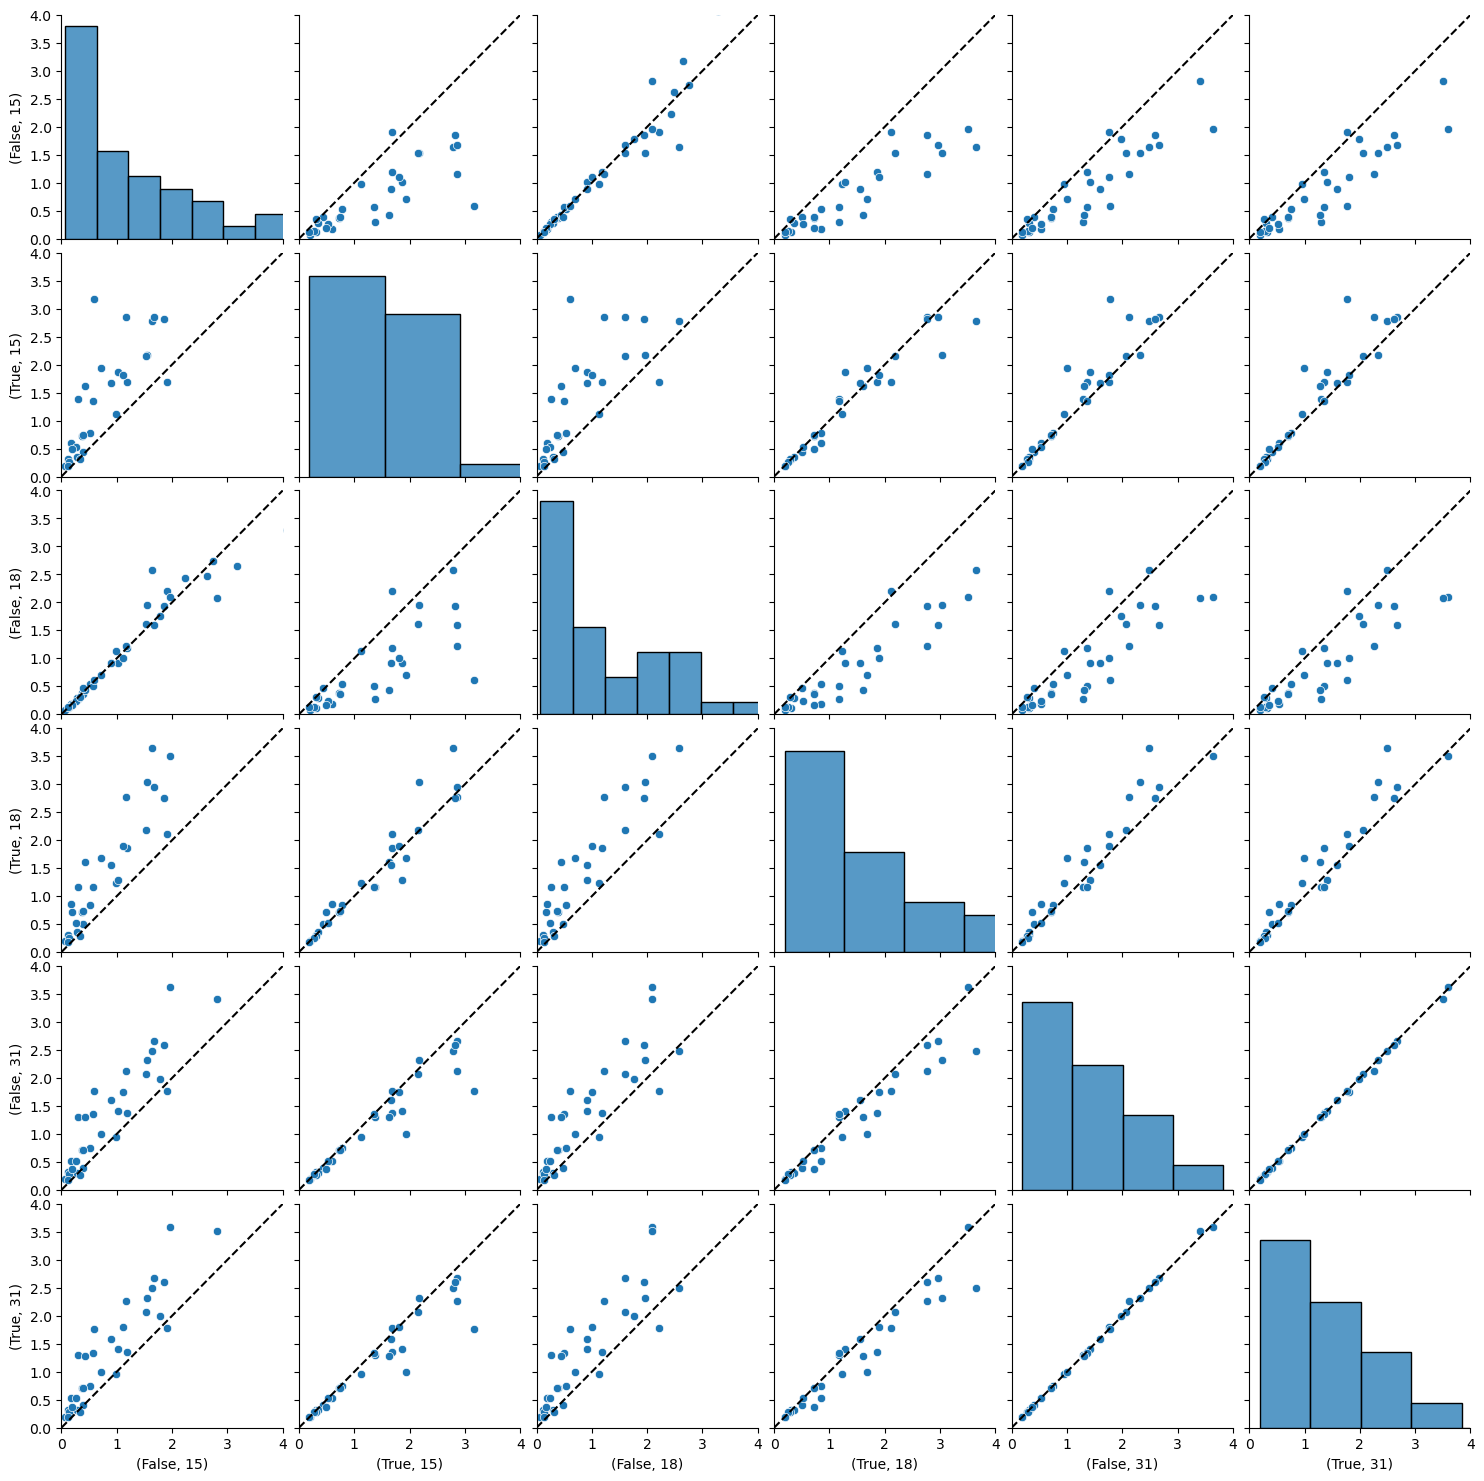

In [35]:
import matplotlib.pyplot as plt
g = sns.pairplot(pars.groupby(['subject', 'model_label', 'many_samples'])[['var_E']].mean().unstack(['many_samples', 'model_label'])['var_E'])

g.map_offdiag(lambda *args, **kwargs: plt.axline(xy1=(0,0), slope=1., c='k', ls='--'))

g.set(xlim=(0, 4), ylim=(0, 4))

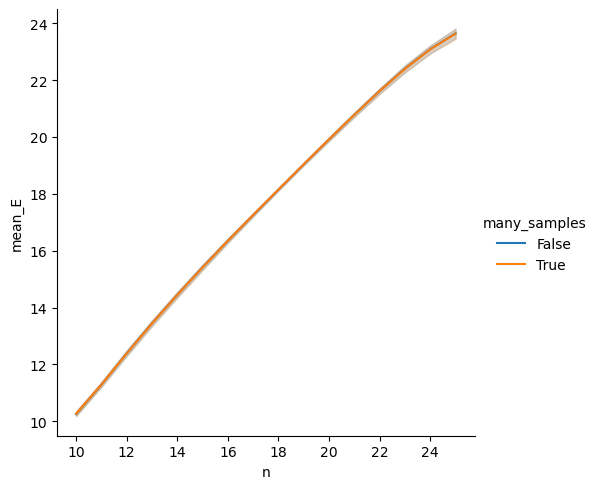

In [ ]:
p = pars.groupby(['subject', 'model_label', 'smoothed', 'many_samples', 'n'])[['mean_E']].mean()

sns.relplot(x='n', y='mean_E', hue='many_samples', data=p.reset_index(), kind='line')

In [38]:
pars

range  \
subject model_label fit_response smoothed spherical_noise many_samples wide               
1       15          False        True     True            False        False 0   narrow   
                                                                             1   narrow   
                                                                             2   narrow   
                                                                             3   narrow   
                                                                             4   narrow   
...                                                                                 ...   
41      31          False        True     True            True         True  57    wide   
                                                                             58    wide   
                                                                             59    wide   
                                                                             60    wide   
                                                                             61    wide   

                                                                                    n  \
subject model_label fit_response smoothed spherical_noise many_samples wide             
1       15          False        True     True            False        False 0   10.0   
                                                                             1   11.0   
                                                                             2   12.0   
                                                                             3   13.0   
                                                                             4   14.0   
...                                                                               ...   
41      31          False        True     True            True         True  57  36.0   
                                                                             58  37.0   
                                                                             59  38.0   
                                                                             60  39.0   
                                                                             61  40.0   

                                                                                    mean_E  \
subject model_label fit_response smoothed spherical_noise many_samples wide                  
1       15          False        True     True            False        False 0   10.611801   
                                                                             1   11.137037   
                                                                             2   12.139342   
                                                                             3   13.040127   
                                                                             4   14.287040   
...                                                                                    ...   
41      31          False        True     True            True         True  57  36.023040   
                                                                             58  37.017834   
                                                                             59  37.963100   
                                                                             60  38.812283   
                                                                             61  39.472120   

                                                                                 mean_error  \
subject model_label fit_response smoothed spherical_noise many_samples wide                   
1       15          False        True     True            False        False 0     0.611800   
                                                                             1     0.137037   
                                                                             2     0.139343   
                                          

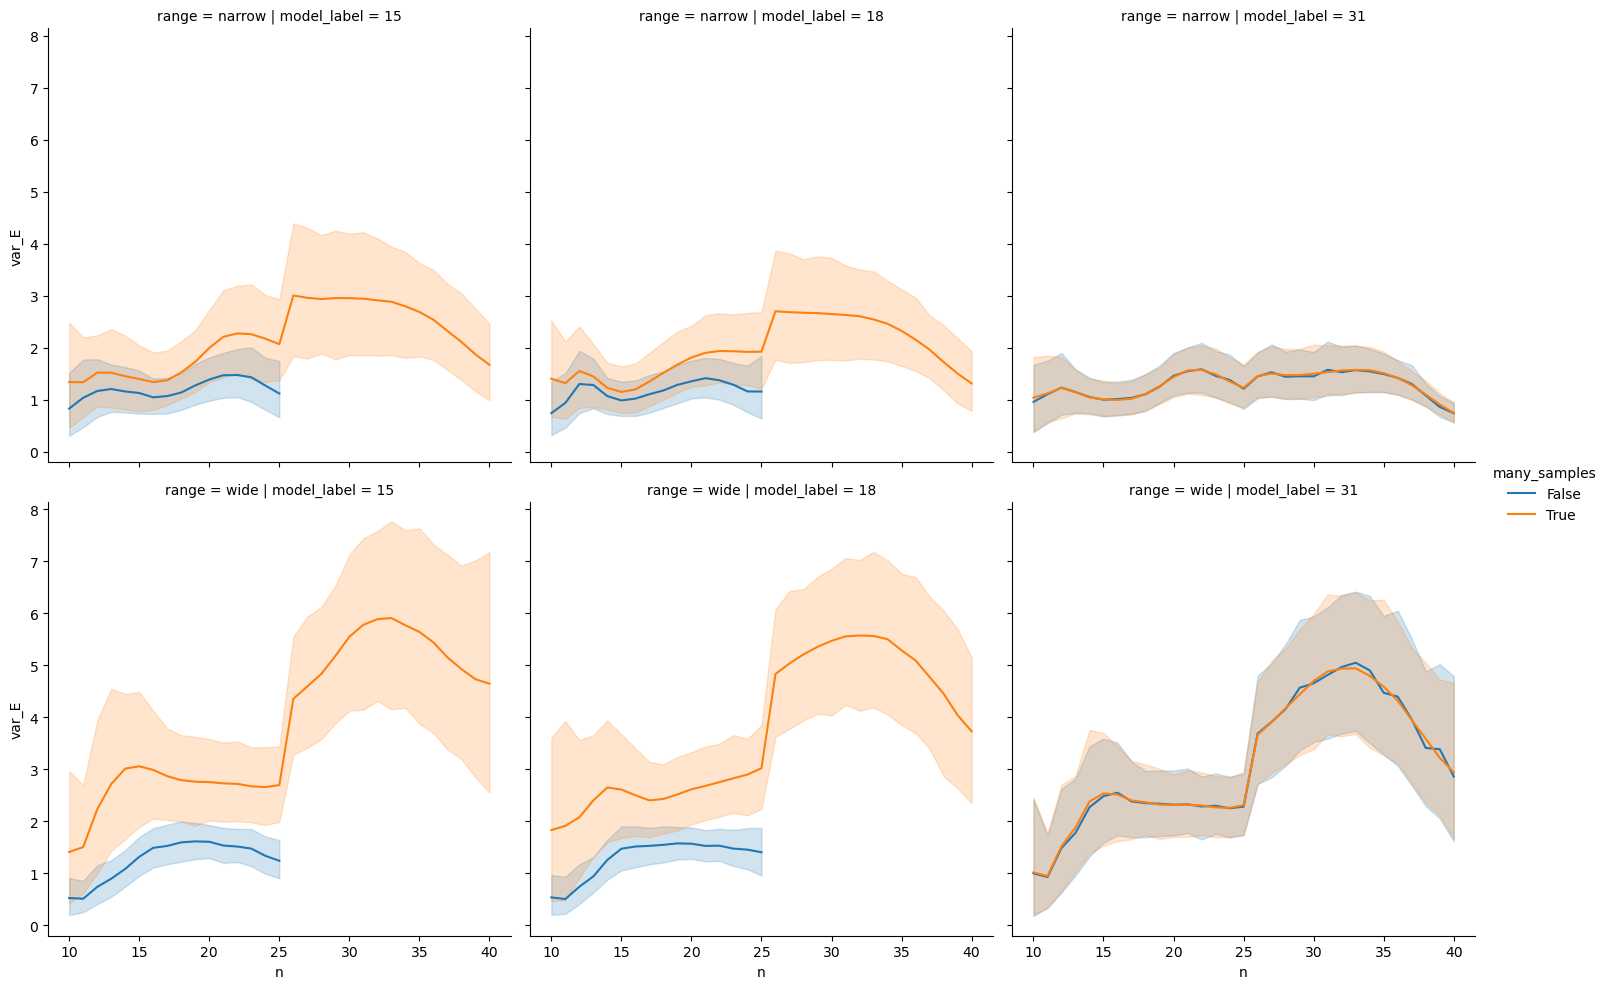

In [37]:
p = pars.groupby(['subject', 'model_label', 'smoothed', 'many_samples', 'n', 'range'])[['var_E']].mean()

sns.relplot(x='n', y='var_E', hue='many_samples', data=p.reset_index(), kind='line', row='range', col='model_label')

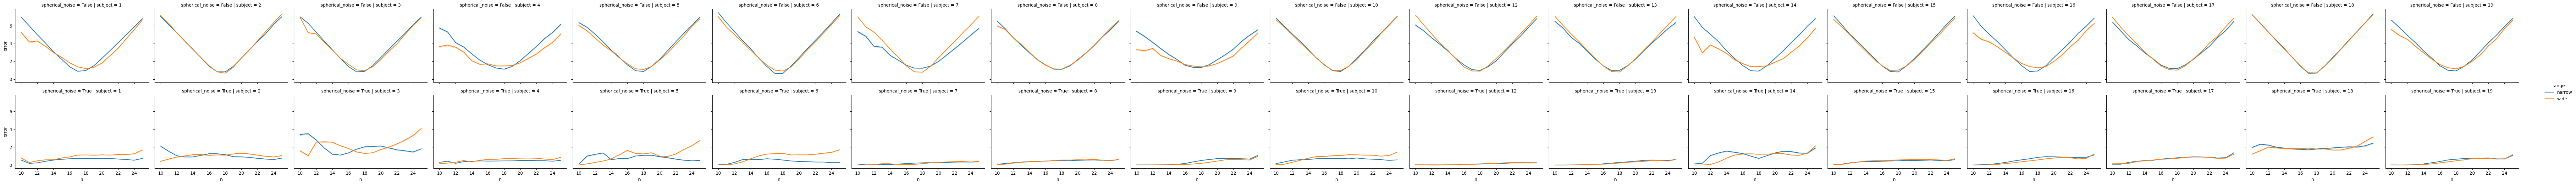

In [109]:
sns.relplot(x='n', y='error', hue='range', data=E.reset_index(), errorbar='se', kind='line', col='subject', height=3, aspect=1.5,
            row='spherical_noise',)

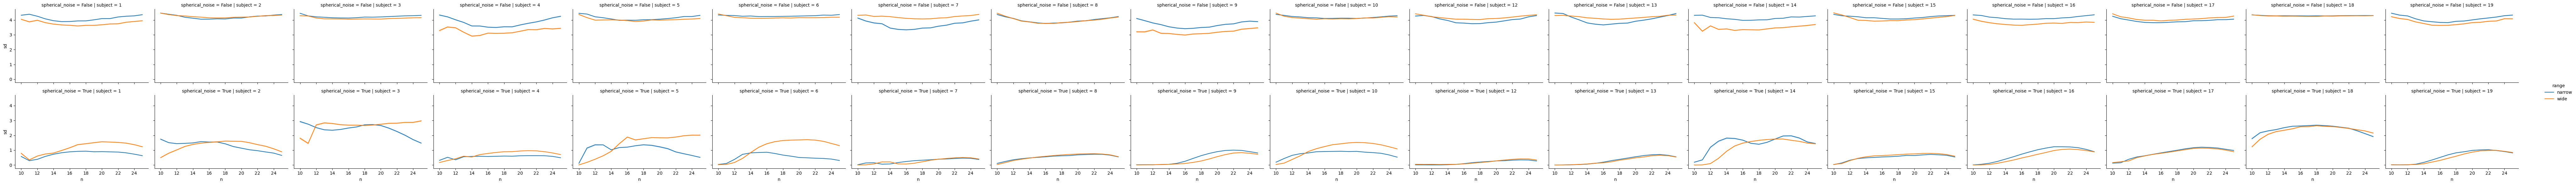

In [110]:
sns.relplot(x='n', y='sd', hue='range', data=sd.reset_index(), errorbar='se', kind='line', col='subject', height=3, aspect=1.5,
            row='spherical_noise')

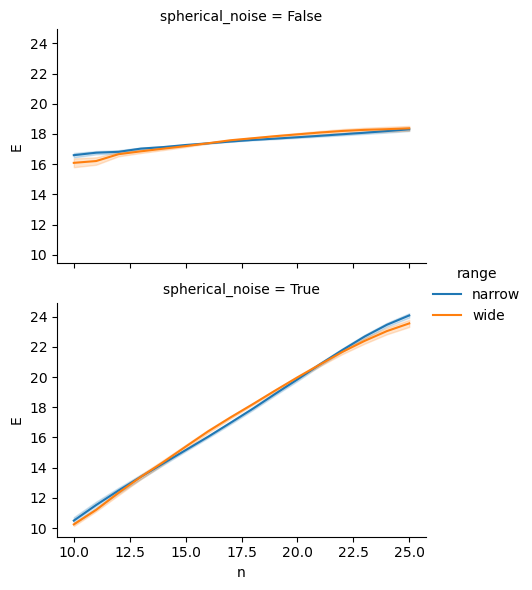

In [111]:
sns.relplot(x='n', y='E', hue='range', data=E.groupby(['subject', 'range', 'n', 'spherical_noise'])[['E']].mean().reset_index(), errorbar='se', kind='line', height=3, aspect=1.5,
            row='spherical_noise')

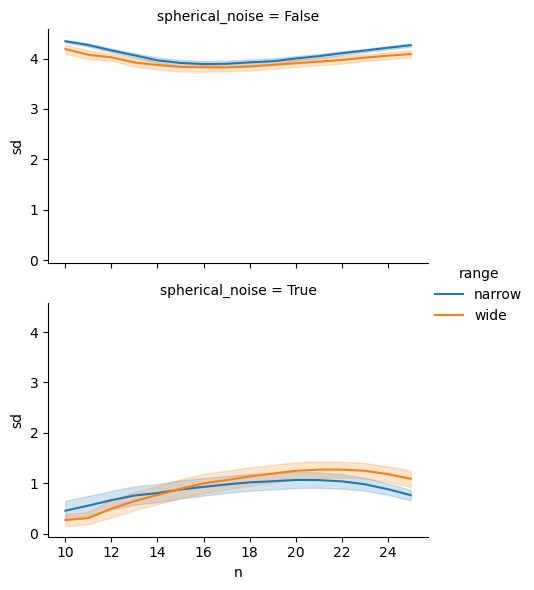

In [112]:
sns.relplot(x='n', y='sd', hue='range', data=sd.groupby(['subject', 'range', 'n', 'spherical_noise'])[['sd']].mean().reset_index(), errorbar='se', kind='line', height=3, aspect=1.5,
            row='spherical_noise')

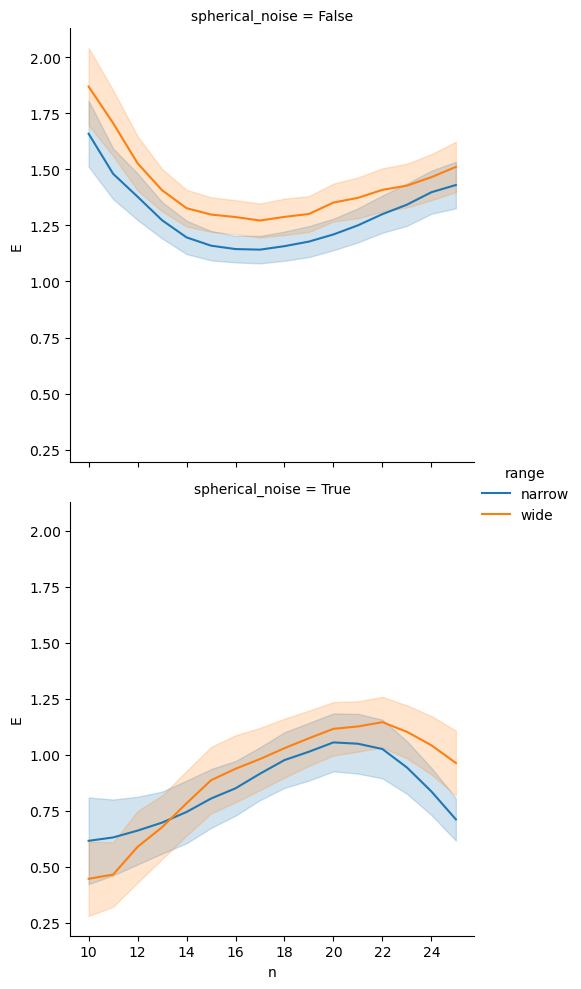

In [113]:
sns.relplot(x='n', y='E', data=E.groupby(['subject', 'range', 'n', 'spherical_noise'])[['E']].std().reset_index(), errorbar='se', kind='line', row='spherical_noise', hue='range')

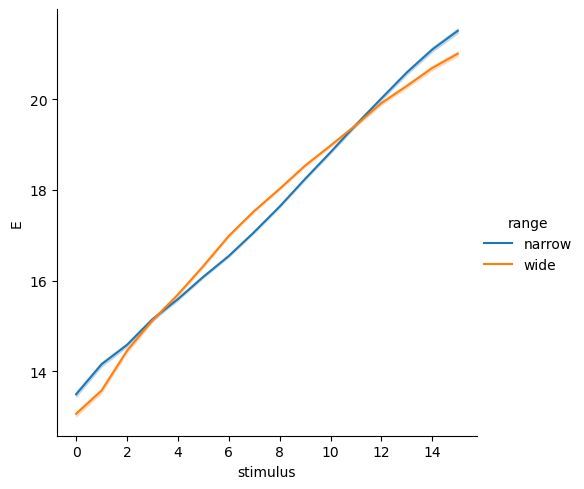

In [102]:
import seaborn as sns
sns.relplot(x='stimulus', y='E', hue='range', data=E, kind='line')

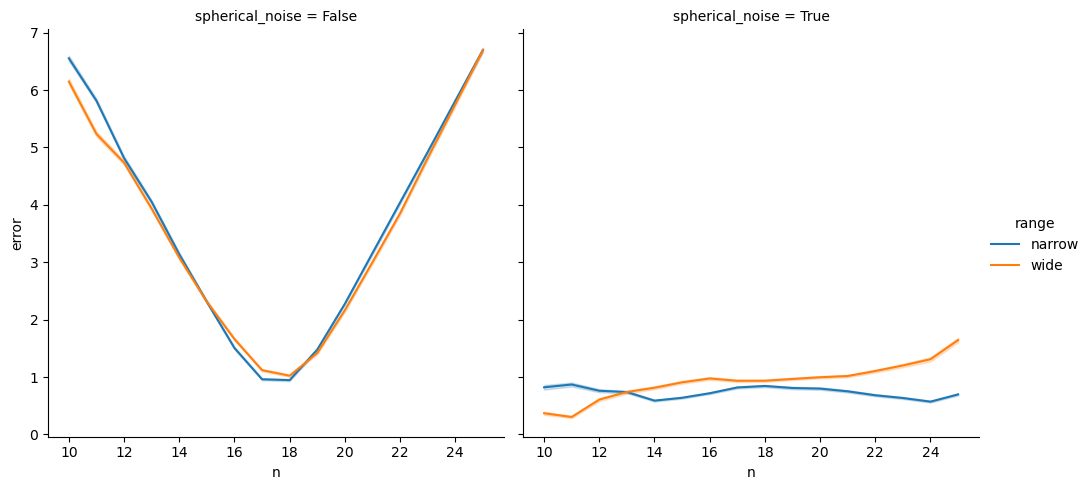

In [106]:
import seaborn as sns
sns.relplot(x='n', y='error', hue='range', data=E, kind='line', col='spherical_noise')

In [27]:
sd = pd.concat((sd_narrow, sd_wide), axis=0, keys=['narrow', 'wide'], names=['range'])

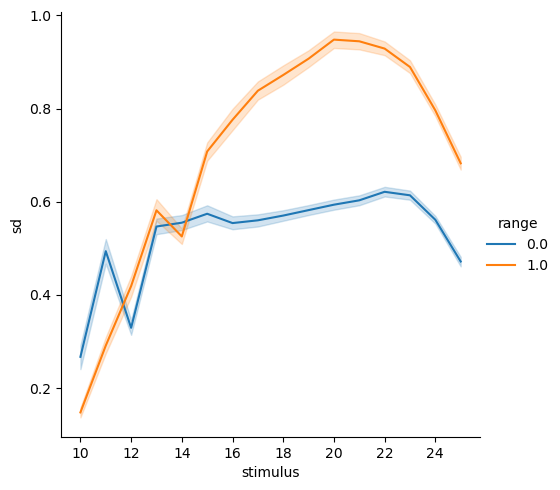

In [28]:
import seaborn as sns
sns.relplot(x='stimulus', y='sd', hue='range', data=sd, kind='line')

In [17]:
get_expected_value(p_stim_narrow, normalize=True).to_frame()

TypeError: Setting a MultiIndex dtype to anything other than object is not supported

In [15]:
narrow_stimuli

,stimulus,range
stimulus,,
0,10.0,0.0
1,11.0,0.0
2,12.0,0.0
3,13.0,0.0
4,14.0,0.0
5,15.0,0.0
6,16.0,0.0
7,17.0,0.0
8,18.0,0.0


In [16]:
E

E  stimulus  range     error
range  repeat stimulus                                      
narrow 0      0         10.015773      10.0    0.0  0.015773
              1         11.164930      11.0    0.0  0.164930
              2         11.410006      12.0    0.0  0.589994
              3         13.057391      13.0    0.0  0.057391
              4         14.004251      14.0    0.0  0.004251
...                           ...       ...    ...       ...
wide   999    11        21.197567      21.0    1.0  0.197567
              12        20.685080      22.0    1.0  1.314920
              13        21.492207      23.0    1.0  1.507793
              14        24.381149      24.0    1.0  0.381149
              15        24.531071      25.0    1.0  0.468929

[32000 rows x 4 columns]

In [3]:
p_stim_narrow

dim_0                    10.0          11.0          12.0          13.0  \
dim_1                     0.0           0.0           0.0           0.0   
repeat stimulus                                                           
0      0         1.000000e+00  3.898673e-03  3.345663e-07  7.214949e-06   
       1         2.894959e-04  1.000000e+00  1.756722e-01  9.957736e-03   
       2         1.427333e-01  1.000000e+00  6.209331e-01  7.119925e-02   
       3         3.583923e-09  2.779198e-02  4.779086e-03  1.000000e+00   
       4         2.310623e-07  2.666636e-04  4.280721e-06  4.488562e-02   
...                       ...           ...           ...           ...   
999    11        0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
       12        3.568770e-29  6.945781e-35  3.720910e-38  7.558977e-37   
       13        1.510133e-36  1.863727e-43  0.000000e+00  0.000000e+00   
       14        5.980861e-34  2.691802e-39  1.545632e-42  9.422891e-41   
       15        0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   

dim_0                    14.0          15.0          16.0          17.0  \
dim_1                     0.0           0.0           0.0           0.0   
repeat stimulus                                                           
0      0         1.155689e-04  4.044476e-04  2.285075e-04  2.525191e-05   
       1         4.534593e-05  6.098113e-08  1.291224e-11  8.826754e-16   
       2         9.234448e-03  1.870946e-03  9.497163e-05  1.138752e-06   
       3         1.268218e-01  4.108933e-05  8.201232e-11  1.289871e-17   
       4         1.000000e+00  5.024651e-02  5.261344e-05  5.953054e-09   
...                       ...           ...           ...           ...   
999    11        0.000000e+00  3.462482e-40  3.274710e-31  2.983662e-22   
       12        6.064653e-33  8.947523e-28  2.064201e-22  2.823621e-17   
       13        2.780176e-41  2.689467e-35  9.554023e-29  3.907255e-22   
       14        3.843350e-37  1.420700e-32  1.159699e-27  1.204626e-22   
       15        0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   

dim_0                    18.0          19.0          20.0          21.0  \
dim_1                     0.0           0.0           0.0           0.0   
repeat stimulus                                                           
0      0         7.782935e-07  8.572234e-09  4.049881e-11  9.795339e-14   
       1         3.213509e-20  7.798377e-25  1.463280e-29  2.501348e-34   
       2         3.593341e-09  3.343983e-12  1.095360e-15  1.636293e-19   
       3         8.907113e-25  5.886840e-32  5.351490e-39  1.401298e-45   
       4         1.959603e-13  3.051861e-18  3.030288e-23  2.496799e-28   
...                       ...           ...           ...           ...   
999    11        6.153757e-14  4.856188e-07  2.019514e-02  1.000000e+00   
       12        1.449642e-12  1.904272e-08  4.347189e-05  1.232961e-02   
       13        8.101121e-16  3.725793e-10  1.552500e-05  2.575913e-02   
       14        1.079143e-17  5.166649e-13  7.719356e-09  2.166313e-05   
       15        3.293840e-39  1.622187e-31  7.210755e-24  1.180618e-16   

dim_0                    22.0          23.0          24.0          25.0  
dim_1                     0.0           0.0           0.0           0.0  
repeat stimulus                                                          
0      0         1.461298e-16  1.617427e-19  1.570888e-22  1.540661e-25  
       1         4.650023e-39  1.107026e-43  0.000000e+00  0.000000e+00  
       2         1.501934e-23  1.125117e-27  8.718258e-32  8.354495e-36  
       3         0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  
       4         2.182440e-33  2.489805e-38  4.330012e-43  0.000000e+00  
...                       ...           ...           ...           ...  
999    11        4.635004e-02  6.172968e-06  1.521898e-11  4.372924e-18  
       12        3.536351e-01  1.000000e+00  3.264906e-01  1.661308e-02  
       13        1.000000e+00  8.

In [5]:
p_stim_narrow.droplevel(1, 1)

dim_0                    10.0          11.0          12.0          13.0  \
repeat stimulus                                                           
0      0         1.000000e+00  3.898673e-03  3.345663e-07  7.214949e-06   
       1         2.894959e-04  1.000000e+00  1.756722e-01  9.957736e-03   
       2         1.427333e-01  1.000000e+00  6.209331e-01  7.119925e-02   
       3         3.583923e-09  2.779198e-02  4.779086e-03  1.000000e+00   
       4         2.310623e-07  2.666636e-04  4.280721e-06  4.488562e-02   
...                       ...           ...           ...           ...   
999    11        0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
       12        3.568770e-29  6.945781e-35  3.720910e-38  7.558977e-37   
       13        1.510133e-36  1.863727e-43  0.000000e+00  0.000000e+00   
       14        5.980861e-34  2.691802e-39  1.545632e-42  9.422891e-41   
       15        0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   

dim_0                    14.0          15.0          16.0          17.0  \
repeat stimulus                                                           
0      0         1.155689e-04  4.044476e-04  2.285075e-04  2.525191e-05   
       1         4.534593e-05  6.098113e-08  1.291224e-11  8.826754e-16   
       2         9.234448e-03  1.870946e-03  9.497163e-05  1.138752e-06   
       3         1.268218e-01  4.108933e-05  8.201232e-11  1.289871e-17   
       4         1.000000e+00  5.024651e-02  5.261344e-05  5.953054e-09   
...                       ...           ...           ...           ...   
999    11        0.000000e+00  3.462482e-40  3.274710e-31  2.983662e-22   
       12        6.064653e-33  8.947523e-28  2.064201e-22  2.823621e-17   
       13        2.780176e-41  2.689467e-35  9.554023e-29  3.907255e-22   
       14        3.843350e-37  1.420700e-32  1.159699e-27  1.204626e-22   
       15        0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   

dim_0                    18.0          19.0          20.0          21.0  \
repeat stimulus                                                           
0      0         7.782935e-07  8.572234e-09  4.049881e-11  9.795339e-14   
       1         3.213509e-20  7.798377e-25  1.463280e-29  2.501348e-34   
       2         3.593341e-09  3.343983e-12  1.095360e-15  1.636293e-19   
       3         8.907113e-25  5.886840e-32  5.351490e-39  1.401298e-45   
       4         1.959603e-13  3.051861e-18  3.030288e-23  2.496799e-28   
...                       ...           ...           ...           ...   
999    11        6.153757e-14  4.856188e-07  2.019514e-02  1.000000e+00   
       12        1.449642e-12  1.904272e-08  4.347189e-05  1.232961e-02   
       13        8.101121e-16  3.725793e-10  1.552500e-05  2.575913e-02   
       14        1.079143e-17  5.166649e-13  7.719356e-09  2.166313e-05   
       15        3.293840e-39  1.622187e-31  7.210755e-24  1.180618e-16   

dim_0                    22.0          23.0          24.0          25.0  
repeat stimulus                                                          
0      0         1.461298e-16  1.617427e-19  1.570888e-22  1.540661e-25  
       1         4.650023e-39  1.107026e-43  0.000000e+00  0.000000e+00  
       2         1.501934e-23  1.125117e-27  8.718258e-32  8.354495e-36  
       3         0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  
       4         2.182440e-33  2.489805e-38  4.330012e-43  0.000000e+00  
...                       ...           ...           ...           ...  
999    11        4.635004e-02  6.172968e-06  1.521898e-11  4.372924e-18  
       12        3.536351e-01  1.000000e+00  3.264906e-01  1.661308e-02  
       13        1.000000e+00  8.393392e-01  2.233148e-02  3.789025e-05  
       14        7.696621e-03  2.777832e-01  1.000000e+00  4.248894e-01  
       15        2.497031e-10  2.362084e-05  4.282494e-02  1.000000e+00  

[16000 rows x 16 columns]

In [9]:
narrow_stimuli

,stimulus,range
0,10.0,0.0
1,11.0,0.0
2,12.0,0.0
3,13.0,0.0
4,14.0,0.0
5,15.0,0.0
6,16.0,0.0
7,17.0,0.0
8,18.0,0.0
9,19.0,0.0


In [11]:
# p_stim_narrow = p_stim_narrow.droplevel(1, 1)
# p_stim_wide = p_stim_wide.droplevel(1, 1)

E_narrow = get_expected_value(p_stim_narrow, normalize=True).to_frame().join(narrow_stimuli)
E_wide = get_expected_value(p_stim_wide, normalize=True).to_frame().join(wide_stimuli)

sd_narrow = get_sd_posterior(p_stim_narrow, normalize=True).to_frame().join(narrow_stimuli)
sd_wide = get_sd_posterior(p_stim_wide, normalize=True).to_frame().join(wide_stimuli)


E = pd.concat((E_narrow, E_wide), axis=0, keys=['narrow', 'wide'], names=['range'])
E['error'] = E['E'] - E['stimulus']
E['error'] = E['error'].abs()

In [ ]:
sns.relplot(x='stimulus', E

E  stimulus  range     error
range  repeat stimulus                                      
narrow 0      0         10.015773      10.0    0.0  0.015773
              1         11.164930      11.0    0.0  0.164930
              2         11.410006      12.0    0.0  0.589994
              3         13.057391      13.0    0.0  0.057391
              4         14.004251      14.0    0.0  0.004251
...                           ...       ...    ...       ...
wide   999    11        21.197567      21.0    1.0  0.197567
              12        20.685080      22.0    1.0  1.314920
              13        21.492207      23.0    1.0  1.507793
              14        24.381149      24.0    1.0  0.381149
              15        24.531071      25.0    1.0  0.468929

[32000 rows x 4 columns]

In [7]:
get_expected_value(p_stim_narrow, normalize=True)

repeat  stimulus
0       0           10.015773
        1           11.164930
        2           11.410006
        3           13.057391
        4           14.004251
                      ...    
999     11          21.024536
        12          22.979235
        13          22.454721
        14          23.946062
        15          24.921022
Name: E, Length: 16000, dtype: float32

In [ ]:
E_narrow = get_expected_value(p_stim_narrow, normalize=True).join(narrow_stimuli)
E_wide = get_expected_value(p_stim_wide, normalize=True).join(wide_stimuli)

sd_narrow = get_sd_posterior(p_stim_narrow, normalize=True).join(narrow_stimuli)
sd_wide = get_sd_posterior(p_stim_wide, normalize=True).join(wide_stimuli)


E = pd.concat((E_narrow, E_wide), axis=0, keys=['narrow', 'wide'], names=['range'])
E['error'] = E['E'] - E['stimulus']
E['error'] = E['error'].abs()

In [8]:
sub = Subject(subject, bids_folder=bids_folder)

pars = sub.get_prf_parameters_volume2(model_label, smoothed=smoothed, roi='NPCr', raw=True)
cvr2 = sub.get_prf_parameters_volume2(model_label, smoothed=smoothed, roi='NPCr', raw=False, par_keys=[])['cvr2'].squeeze()
print(cvr2)
mask = cvr2 > 0.0
print(mask)
pars = pars.loc[mask, :]

# Create target folder
key = f'model{model_label}'

if smoothed:
    key += '.smoothed'

if fit_responses:
    key += '.fit_responses'

target_dir = Path(bids_folder) / 'derivatives' / 'fisher_information2' / key / f'sub-{subject:02d}' / 'func'
target_dir.mkdir(parents=True, exist_ok=True)


# Get paradigm/data/model
paradigm = get_paradigm(sub, fit_responses=fit_responses)
data = sub.get_single_trial_estimates(session=None, smoothed=smoothed)
masker = sub.get_volume_mask(roi=roi, epi_space=True, return_masker=True)
data = pd.DataFrame(masker.fit_transform(data), index=paradigm.index).astype(np.float32)

data = data.loc[:, mask]

model = get_model(model_label)

pred = model.predict(paradigm, pars)

r2 = get_rsq(data, pred)

print(r2.sort_values())

narrow_stimuli = np.concatenate((np.arange(10, 26, 1)[:, np.newaxis], np.zeros(16)[:, np.newaxis]), axis=1)
wide_stimuli = np.concatenate((np.arange(10, 41, 1)[:, np.newaxis], np.ones(31)[:, np.newaxis]), axis=1)
stimuli = np.concatenate((narrow_stimuli, wide_stimuli), axis=0).astype(np.float32)



model.init_pseudoWWT(narrow_stimuli, pars)
resid_fitter = ResidualFitter(model, data, paradigm, pars)
omega_narrow, dof = resid_fitter.fit(spherical=False)

model.init_pseudoWWT(wide_stimuli, pars)
resid_fitter = ResidualFitter(model, data, paradigm, pars)
omega_wide, dof = resid_fitter.fit(spherical=True)

# pd.DataFrame(omega).to_csv(target_dir / f'sub-{subject:02d}_desc-omega.tsv', sep='\t')
# fisher_information = model.get_fisher_information(stimuli, omega)

# fisher_information = fisher_information.to_frame('fisher_information')
# fisher_information.index.names = ['n', 'wide']
# fisher_information = fisher_information.reset_index()

# fisher_information['condition'] = fisher_information['wide'].map({0: 'narrow', 1: 'wide'})
# fisher_information.drop('wide', axis=1).to_csv(target_dir / f'sub-{subject:02d}_desc-fisher_information.tsv', sep='\t')

0      0.000634
1     -0.014923
2     -0.007084
3     -0.008669
4     -0.009068
         ...   
770   -0.013853
771   -0.025739
772   -0.021288
773   -0.014519
774   -0.018508
Name: nan, Length: 775, dtype: float32
0       True
1      False
2      False
3      False
4      False
       ...  
770    False
771    False
772    False
773    False
774    False
Name: nan, Length: 775, dtype: bool


125    0.005168
428    0.005532
440    0.005774
0      0.006470
190    0.007819
         ...   
261    0.061855
189    0.062279
253    0.063064
148    0.063948
243    0.071007
Name: r2, Length: 216, dtype: float32
init_tau: 0.3173433542251587, 1.1196236610412598
USING A PSEUDO-WWT!
WWT max: 14.196720123291016


  0%|          | 0/1000 [00:00<?, ?it/s]

init_tau: 0.3173433542251587, 1.1196236610412598


  0%|          | 0/1000 [00:00<?, ?it/s]

In [3]:
wwt_narrow =  model.init_pseudoWWT(narrow_stimuli, pars)
# omega_narrow, dof = resid_fitter.fit()

wwt_wide = model.init_pseudoWWT(wide_stimuli, pars)
# omega_wide, dof = resid_fitter.fit()

In [4]:
narrow_stimuli = np.concatenate((np.arange(10, 26, 1)[:, np.newaxis], np.zeros(16)[:, np.newaxis]), axis=1)
wide_stimuli = np.concatenate((np.arange(10, 26, 1)[:, np.newaxis], np.ones(16)[:, np.newaxis]), axis=1)
# wide_stimuli = np.concatenate((np.arange(10, 41, 1)[:, np.newaxis], np.ones(31)[:, np.newaxis]), axis=1)
stimuli = np.concatenate((narrow_stimuli, wide_stimuli), axis=0).astype(np.float32)


In [5]:
stimuli = pd.DataFrame(stimuli, columns=['x', 'condition'])

stimuli.index.set_names('stimulus', inplace=True)

omega = np.identity(omega.shape[0]).astype(np.float32) * omega.astype(np.float32)

NameError: name 'omega' is not defined

In [ ]:
# omega = np.identity(omega.shape[0]).astype(np.float32)
simulated_data = model.simulate(stimuli, pars, noise=omega, n_repeats=1000)

In [9]:
p_stim =  model.get_stimulus_pdf(simulated_data, parameters=pars, omega=omega, stimulus_range=stimuli, normalize=False)

NameError: name 'simulated_data' is not defined

In [10]:
p_stim

NameError: name 'p_stim' is not defined

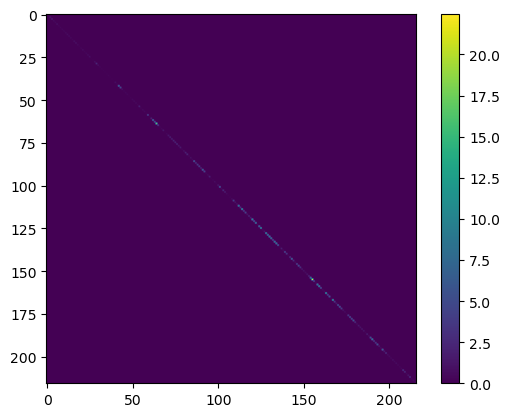

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.imshow(omega)

plt.colorbar()

In [ ]:
E0 = get_expected_value(p_stim.xs(0.0, level=1, axis=1), normalize=True).to_frame().join(stimuli)
E1 = get_expected_value(p_stim.xs(1.0, level=1, axis=1), normalize=True).to_frame().join(stimuli)


sd0 = get_sd_posterior(p_stim.xs(0.0, level=1, axis=1), normalize=True).to_frame().join(stimuli)
sd1 = get_sd_posterior(p_stim.xs(1.0, level=1, axis=1), normalize=True).to_frame().join(stimuli)



In [ ]:
E = E0.where(E0['condition'] == 0.0, E1)
sd = sd0.where(sd0['condition'] == 0.0, sd1)

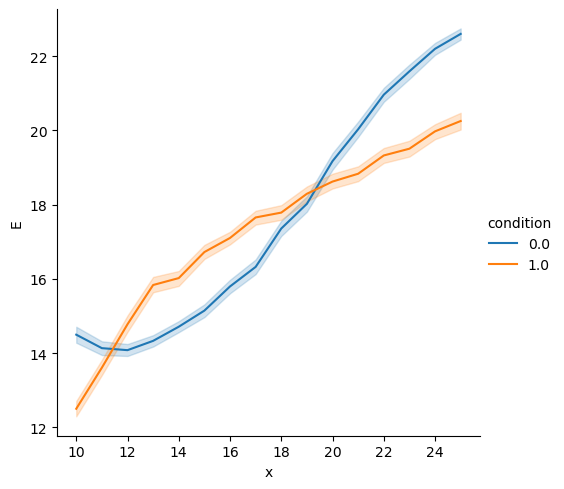

In [ ]:
sns.relplot(x='x', y='E', data=E, hue='condition', kind='line')

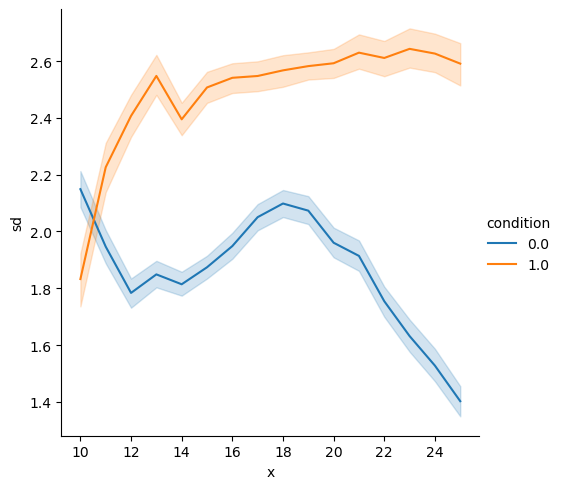

In [ ]:
import seaborn as sns
sns.relplot(x='x', y='sd', hue='condition', data=sd, kind='line')

In [ ]:
E

E     x  condition
repeat stimulus                            
0      0         10.395796  10.0        0.0
       1         14.970292  11.0        0.0
       2         12.500819  12.0        0.0
       3         12.510507  13.0        0.0
       4         17.119488  14.0        0.0
...                    ...   ...        ...
999    27        16.526037  21.0        1.0
       28        22.216694  22.0        1.0
       29        17.652958  23.0        1.0
       30        18.563597  24.0        1.0
       31        10.080389  25.0        1.0

[32000 rows x 3 columns]

In [11]:
paradigm

x  range
subject session run trial_nr             
04      1       1   1         40.0    1.0
                    2         25.0    1.0
                    3         13.0    1.0
                    4         27.0    1.0
                    5         13.0    1.0
...                            ...    ...
        2       8   26        19.0    1.0
                    27        37.0    1.0
                    28        13.0    1.0
                    29        23.0    1.0
                    30        40.0    1.0

[480 rows x 2 columns]

In [ ]:
E['error'] = E['E'] - E['x']
E['abs(error)'] = np.abs(E['error'])

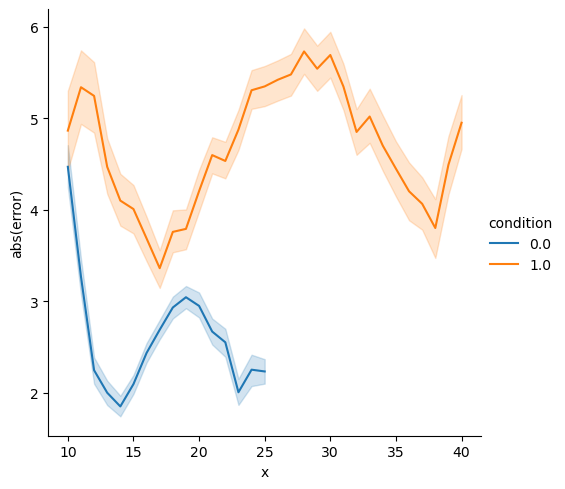

In [ ]:
sns.relplot(x='x', y='abs(error)', data=E, hue='condition', kind='line')